# Random Forest high20 con verdad `Jet.Flavor`

## Conclusión ejecutiva

El resultado actual separa jets `b` de fondos definidos por verdad de Delphes con AUC de prueba cercano a 0.91. El umbral se seleccionó en validación, no en prueba, y las variables de parámetro de impacto dominan la decisión; `jet_pt` tiene importancia marginal. Este resultado es la referencia física más informativa de las tres comparadas, pero **las métricas no son directamente equivalentes**: cambian etiquetas, mezcla de fuentes y protocolo de evaluación.

## 1. Mapa de la tubería

| Etapa | Operación | Evidencia |
|---|---|---|
| 1 | Auditoría ROOT y perfil `high20` | `input_audit.json`, `source_profiles.json` |
| 2 | Etiquetado físico | `Jet.Flavor` a `b/c/g/uds`; se excluye `0` |
| 3 | División por evento | parquet train/val/test sin eventos compartidos |
| 4 | Random Forest | métricas, puntuaciones indexadas e importancias |
| 5 | Este cuaderno | comprobaciones, tablas y figuras regeneradas |

## 2. Configuración reproducible y comprobación de artefactos

El cuaderno debe ejecutarse desde la raíz del repositorio. Todas las lecturas son relativas; si falta un artefacto, la ejecución se detiene antes de interpretar resultados.

In [1]:
from pathlib import Path
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import auc, roc_curve

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks' and (ROOT.parent / 'ml').is_dir():
    ROOT = ROOT.parent
os.chdir(ROOT)
if not (ROOT / 'ml').is_dir():
    raise RuntimeError('Ejecute el cuaderno desde la raíz del repositorio.')
DATASET_DIR = Path('outputs/high20_jet_flavor')
RF_DIR = Path('outputs/rf_high20_jet_flavor')
ARTIFACTS = {
    'profile': Path('ml/source_profiles.json'), 'manifest': DATASET_DIR / 'dataset_manifest.json',
    'train': DATASET_DIR / 'train.parquet', 'val': DATASET_DIR / 'val.parquet',
    'test': DATASET_DIR / 'test.parquet', 'metrics': RF_DIR / 'rf_metrics.json',
    'importance': RF_DIR / 'rf_feature_importance.csv', 'scores': RF_DIR / 'rf_test_scores.csv',
}
missing = [str(path) for path in ARTIFACTS.values() if not path.is_file()]
if missing:
    raise FileNotFoundError('Faltan artefactos requeridos:\n' + '\n'.join(missing))
def load_json(path):
    with path.open(encoding='utf-8') as handle:
        return json.load(handle)
profiles, manifest, metrics = (load_json(ARTIFACTS[key]) for key in ('profile', 'manifest', 'metrics'))
train, val, test = (pd.read_parquet(ARTIFACTS[key]) for key in ('train', 'val', 'test'))
importance, scores = pd.read_csv(ARTIFACTS['importance']), pd.read_csv(ARTIFACTS['scores'])
assert len(scores) == len(test) == manifest['n_test_jets']
assert set(['global_event_id', 'sample_label', 'is_b', 'score_rf']).issubset(scores.columns)
print(f'Listo: {len(ARTIFACTS)} artefactos actuales cargados desde rutas relativas.')

Listo: 8 artefactos actuales cargados desde rutas relativas.


## 3. Auditoría de entrada y procedencia ROOT

El perfil `high20` es una selección de procedencia, independiente de `--pt-region`. El manifest registra siete ROOT válidos y ningún archivo inválido.

In [2]:
high20 = profiles['profiles']['high20']
audit = manifest['input_audit']
assert manifest['source_profile'] == 'high20' and audit['valid_file_count'] == 7
assert 'independent from --pt-region' in high20['description']
provenance = pd.DataFrame(audit['valid_files'])
provenance['file'] = provenance['file'].map(lambda value: str(Path(Path(value).parent.name) / Path(value).name))
display(provenance.rename(columns={'file': 'ROOT relativo a data_dir', 'label': 'fuente'}))
print(f"Perfil: {manifest['source_profile']} | pt_region registrado: {manifest['pt_region']} | ROOT válidos: {audit['valid_file_count']}")

,ROOT relativo a data_dir,fuente
0,QCD_bbbar/run_01_delphes_events.root,b
1,QCD_bbbar/run_02_delphes_events.root,b
2,QCD_ccbar/run_01_delphes_events.root,c
3,QCD_gg/run_01_delphes_events.root,g
4,QCD_gg/run_02_delphes_events.root,g
5,QCD_uds/run_01_delphes_events.root,uds
6,QCD_uds/run_02_delphes_events.root,uds


Perfil: high20 | pt_region registrado: all | ROOT válidos: 7


## 4. Mapeo de verdad y contabilidad de jets

La definición es `abs(Flavor)==5 → b`, `abs(Flavor)==4 → c`, `Flavor==21 → g` y `abs(Flavor)∈{1,2,3} → uds`. Los jets con `Jet.Flavor==0` no tienen una de estas etiquetas y se excluyen antes de la división.

In [3]:
truth = manifest['label_source']['truth_summary']
totals = pd.Series(manifest['target_class_counts_by_split']['full'], name='jets').rename_axis('verdad')
accounting = pd.DataFrame({'cantidad': [truth['matched_jets'] + truth['unmatched_jets'], truth['matched_jets'], truth['unmatched_jets']]}, index=['pre-verdad', 'emparejados', 'excluidos: Flavor=0'])
display(accounting)
display(totals.to_frame())
assert totals.sum() == truth['matched_jets'] == manifest['n_full_jets']
print('El conteo pre-verdad y los totales por verdad coinciden con el manifest.')

,cantidad
pre-verdad,456741
emparejados,364749
excluidos: Flavor=0,91992


,jets
verdad,
b,91361
c,58981
g,69402
uds,145005


El conteo pre-verdad y los totales por verdad coinciden con el manifest.


## 5. Fuente frente a verdad

La fila representa la carpeta/fuente y la columna la verdad por jet. La pureza indicada es la fracción de la clase de verdad que coincide con el nombre de la fuente. En particular, la fuente `g` no es una muestra pura de jets `g`: una fracción importante es `uds`.

,b,c,g,uds
b,89640,925,7755,6448
c,194,50759,3979,3184
g,1185,4810,49356,37270
uds,342,2487,8312,98103


,truth purity (%)
b,85.56
c,87.34
g,53.29
uds,89.80


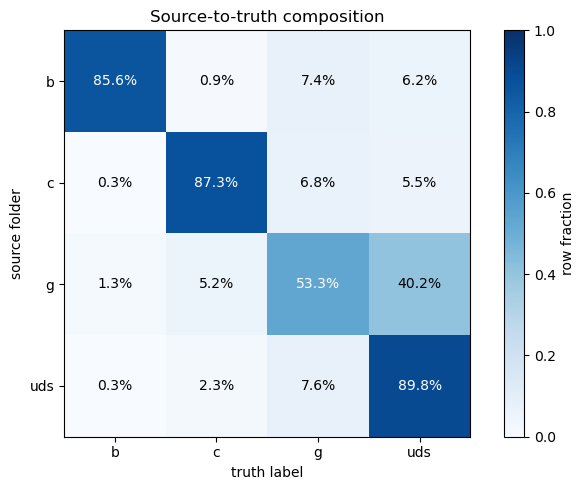

In [4]:
order = ['b', 'c', 'g', 'uds']
contingency = pd.DataFrame(manifest['source_target_contingency']).T.reindex(index=order, columns=order)
normalized = contingency.div(contingency.sum(axis=1), axis=0)
purity = pd.DataFrame({'truth purity (%)': np.diag(normalized) * 100}, index=order)
display(contingency)
display(purity.round(2))
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(normalized, cmap='Blues', vmin=0, vmax=1)
ax.set(xticks=range(4), xticklabels=order, yticks=range(4), yticklabels=order, xlabel='truth label', ylabel='source folder', title='Source-to-truth composition')
for row in range(4):
    for col in range(4): ax.text(col, row, f'{normalized.iloc[row, col]:.1%}', ha='center', va='center', color='white' if normalized.iloc[row, col] > .5 else 'black')
fig.colorbar(image, ax=ax, label='row fraction'); plt.tight_layout(); plt.show()

## 6. División, composición y validación de `pT`

La división es estratificada por eventos y por procedencia. Los siguientes cálculos se hacen de nuevo desde los parquet, incluida la ausencia de intersección de `global_event_id`; los mínimos de `jet_pt` deben ser superiores a 22 GeV.

In [5]:
splits = {'train': train, 'val': val, 'test': test}
split_summary = pd.DataFrame({name: {'jets': len(frame), 'events': frame['global_event_id'].nunique(), 'min jet_pt': frame['jet_pt'].min(), 'max jet_pt': frame['jet_pt'].max()} for name, frame in splits.items()}).T
display(split_summary)
events = {name: set(frame['global_event_id']) for name, frame in splits.items()}
overlap = {'train-val': len(events['train'] & events['val']), 'train-test': len(events['train'] & events['test']), 'val-test': len(events['val'] & events['test'])}
display(pd.Series(overlap, name='shared events').to_frame())
assert not any(overlap.values()) and (split_summary['min jet_pt'] > 22).all()
assert split_summary['jets'].astype(int).to_dict() == {name: manifest[f'n_{name}_jets'] for name in splits}
print('División disjunta por eventos y pT validado desde los parquet.')

,jets,events,min jet_pt,max jet_pt
train,255114.0,170393.0,22.046392,382.396729
val,54936.0,36513.0,22.040003,243.207474
test,54699.0,36513.0,22.076591,316.663452


,shared events
train-val,0
train-test,0
val-test,0


División disjunta por eventos y pT validado desde los parquet.


## 7. Configuración RF y métricas principales

El punto de operación usa el umbral seleccionado con validación para una eficiencia objetivo de `b` del 70%. La prueba se usa sólo para medir el resultado de esa elección.

In [6]:
op = metrics['operating_point']['test_metrics']
headline = pd.DataFrame([{'validation AUC': metrics['validation_auc'], 'test AUC': metrics['test_auc'], 'threshold': op['threshold'], 'test b efficiency': op['b_efficiency'], 'features': metrics['feature_count']}])
display(pd.DataFrame([metrics['rf_configuration']]))
display(headline.round(6))
assert metrics['operating_point']['threshold_source'] == 'validation'
print('Las métricas se cargaron de rf_metrics.json; no se codificaron como constantes.')

,seed,n_estimators,max_depth,min_samples_leaf,class_weight,n_jobs
0,42,100,10,20,balanced,-1


,validation AUC,test AUC,threshold,test b efficiency,features
0,0.909067,0.9114,0.646717,0.709255,32


Las métricas se cargaron de rf_metrics.json; no se codificaron como constantes.


## 8. Distribuciones de puntuación por verdad

Las puntuaciones están indexadas por evento y jet. La separación por `sample_label` utiliza la verdad preservada en `rf_test_scores.csv`, no la carpeta de procedencia.

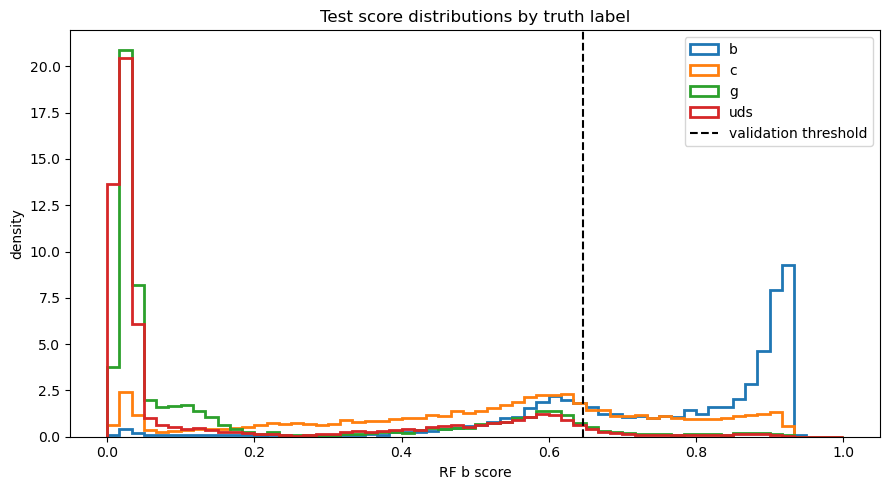

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for label in order:
    ax.hist(scores.loc[scores['sample_label'].eq(label), 'score_rf'], bins=60, range=(0, 1), density=True, histtype='step', linewidth=2, label=label)
ax.axvline(op['threshold'], color='black', linestyle='--', label='validation threshold')
ax.set(xlabel='RF b score', ylabel='density', title='Test score distributions by truth label'); ax.legend(); plt.tight_layout(); plt.show()

## 9. ROC y rechazo de fondo

La ROC binaria agrupa `c/g/uds` como no-`b`. La tabla conserva el desglose por verdad en el umbral de validación: `mistag = P(score ≥ threshold | background)` y `rejection = 1/mistag`.

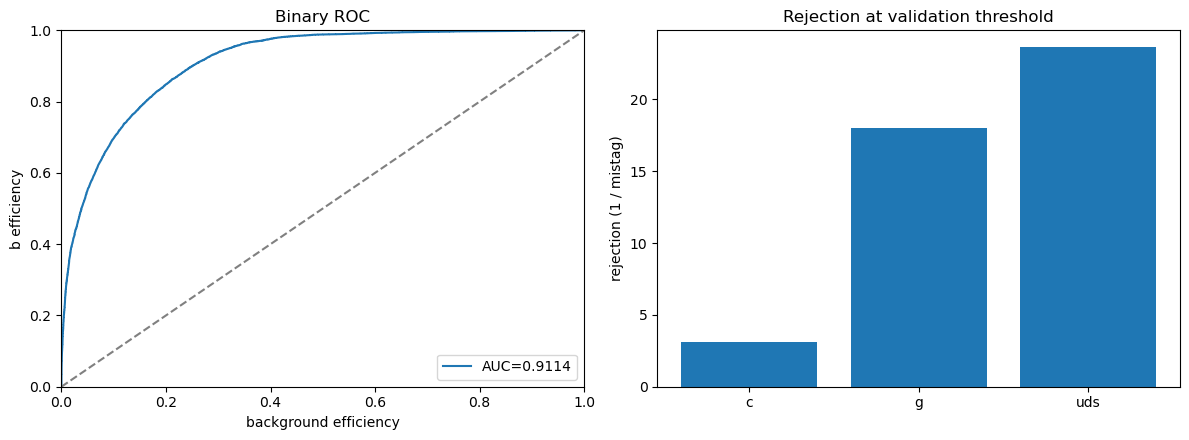

,mistag,rejection
truth background,,
c,0.319942,3.125570
g,0.055545,18.003448
uds,0.042328,23.625272


La tabla recalculada desde puntuaciones coincide con rf_metrics.json.


In [8]:
fpr, tpr, _ = roc_curve(scores['is_b'], scores['score_rf'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.4f}"); axes[0].plot([0, 1], [0, 1], '--', color='grey'); axes[0].set(xlabel='background efficiency', ylabel='b efficiency', title='Binary ROC', xlim=(0, 1), ylim=(0, 1)); axes[0].legend()
rows = []
for label in ['c', 'g', 'uds']:
    mistag = (scores.loc[scores['sample_label'].eq(label), 'score_rf'] >= op['threshold']).mean()
    rows.append({'truth background': label, 'mistag': mistag, 'rejection': 1 / mistag})
operating = pd.DataFrame(rows).set_index('truth background')
axes[1].bar(operating.index, operating['rejection']); axes[1].set(ylabel='rejection (1 / mistag)', title='Rejection at validation threshold')
plt.tight_layout(); plt.show()
display(operating.round(6))
for label, row in operating.iterrows(): assert np.isclose(row['mistag'], op[f'{label}_mistag'])
print('La tabla recalculada desde puntuaciones coincide con rf_metrics.json.')

## 10. Importancia de variables

Se muestran las 15 importancias de impureza más altas. Las variables de impacto (`d0`, `dz`) dominan, mientras que `jet_pt` se reporta explícitamente para evitar atribuir al corte cinemático una separación que no aporta el modelo.

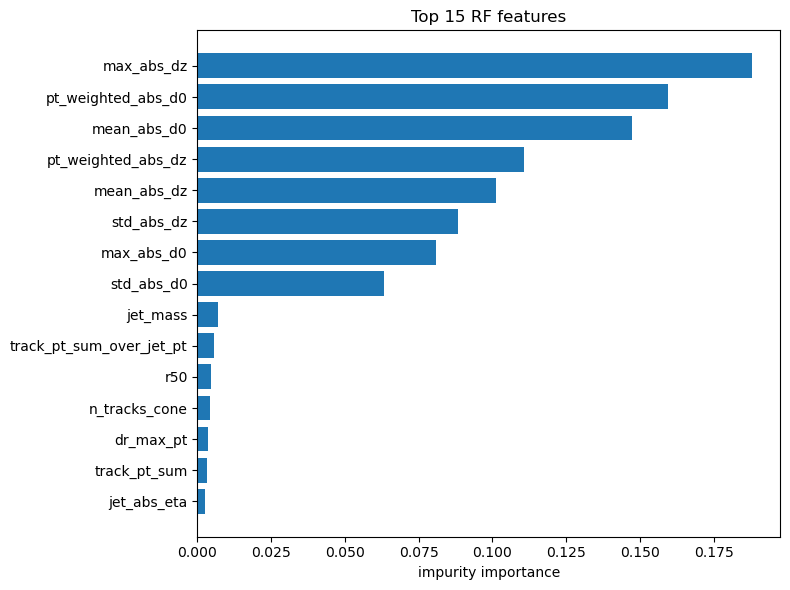

,feature,importance
0,max_abs_dz,0.188053
1,pt_weighted_abs_d0,0.159563
2,mean_abs_d0,0.147229
3,pt_weighted_abs_dz,0.110776
4,mean_abs_dz,0.101314
5,std_abs_dz,0.088338
6,max_abs_d0,0.080919
7,std_abs_d0,0.063296
8,jet_mass,0.006904
9,track_pt_sum_over_jet_pt,0.005687


jet_pt importance = 0.0013225; las variables d0/dz encabezan la lista.


In [9]:
top15 = importance.nlargest(15, 'importance').sort_values('importance')
jet_pt_importance = importance.loc[importance['feature'].eq('jet_pt'), 'importance'].iloc[0]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15['feature'], top15['importance']); ax.set(xlabel='impurity importance', title='Top 15 RF features'); plt.tight_layout(); plt.show()
display(top15.sort_values('importance', ascending=False).reset_index(drop=True))
print(f"jet_pt importance = {jet_pt_importance:.7f}; las variables d0/dz encabezan la lista.")

## 11. Comparación histórica con advertencia de no equivalencia

**No comparar estas columnas como una competencia directa.** Tomás usó etiquetas de carpeta `b/uds` y seleccionó el umbral en prueba; el piloto previo también usa `b/uds` de procedencia, aunque selecciona en validación. El resultado actual usa verdad `Jet.Flavor`, cuatro componentes de fondo y un perfil high20. Los valores de Tomás son auditados/transcritos del cuaderno original, no se recalculan aquí mediante extracción frágil de sus salidas.

In [10]:
pilot_path = Path('outputs/rf_pilot_gt20/rf_metrics.json')
pilot = load_json(pilot_path) if pilot_path.is_file() else None
comparison = pd.DataFrame([
    {'run': 'Tomás (audited/transcribed)', 'labels/background': 'folder b/uds', 'AUC test': 0.864201, 'threshold protocol': 'selected on test', 'b efficiency': 0.70, 'light mistag': 0.177384, 'light rejection': 5.6375, 'jet_pt importance': 0.349217},
    {'run': 'Prior b/uds pilot (loadable)', 'labels/background': 'source b/uds', 'AUC test': pilot['test_auc'], 'threshold protocol': pilot['operating_point']['threshold_source'], 'b efficiency': pilot['operating_point']['test_metrics']['b_efficiency'], 'light mistag': pilot['operating_point']['test_metrics']['uds_mistag'], 'light rejection': pilot['operating_point']['test_metrics']['uds_rejection'], 'jet_pt importance': pd.read_csv('outputs/rf_pilot_gt20/rf_feature_importance.csv').query("feature == 'jet_pt'")['importance'].iloc[0]},
    {'run': 'Current high20 truth (loadable)', 'labels/background': 'Jet.Flavor b vs c/g/uds', 'AUC test': metrics['test_auc'], 'threshold protocol': metrics['operating_point']['threshold_source'], 'b efficiency': op['b_efficiency'], 'light mistag': op['uds_mistag'], 'light rejection': op['uds_rejection'], 'jet_pt importance': jet_pt_importance},
])
display(comparison.round(6))
print('Tomás: 20menos fue procedencia (bbbar 08/09 + uds 05/06), no jet_pt<20; 164,894/602,944 jets estaban sobre 20 GeV. Sólo 22.85% de sus jets b por carpeta tenían Jet.Flavor==5.')

,run,labels/background,AUC test,threshold protocol,b efficiency,light mistag,light rejection,jet_pt importance
0,Tomás (audited/transcribed),folder b/uds,0.864201,selected on test,0.700000,0.177384,5.637500,0.349217
1,Prior b/uds pilot (loadable),source b/uds,0.881608,validation,0.697716,0.122526,8.161504,0.008029
2,Current high20 truth (loadable),Jet.Flavor b vs c/g/uds,0.911400,validation,0.709255,0.042328,23.625272,0.001322


Tomás: 20menos fue procedencia (bbbar 08/09 + uds 05/06), no jet_pt<20; 164,894/602,944 jets estaban sobre 20 GeV. Sólo 22.85% de sus jets b por carpeta tenían Jet.Flavor==5.


## 12. Qué puede y no puede concluirse

**Puede concluirse:** la discriminación actual está validada en una prueba disjunta por evento; el umbral no fue ajustado en prueba; los parámetros de impacto explican la mayor parte de la importancia del RF; y el fondo `c` es sensiblemente más difícil que `g` y `uds`.

**No puede concluirse:** que este AUC sea una ganancia directa sobre Tomás; que las etiquetas de carpeta sean verdad física; que la importancia de impureza sea una causalidad; ni que siete ROOT agoten las sistemáticas de producción y detector.

## 13. Mapa guiado de archivos

| Inspeccionar primero | Contenido |
|---|---|
| `outputs/rf_high20_jet_flavor/rf_metrics.json` | AUC, umbral de validación y punto de operación |
| `outputs/rf_high20_jet_flavor/rf_test_scores.csv` | puntuaciones indexadas por evento/jet y verdad |
| `outputs/high20_jet_flavor/dataset_manifest.json` | definición de verdad, fuentes, conteos y split |
| `outputs/rf_high20_jet_flavor/rf_feature_importance.csv` | importancia de las 32 variables |
| `outputs/high20_jet_flavor/{train,val,test}.parquet` | filas usadas para validar composición, eventos y pT |
| `ml/source_profiles.json` | perfil `high20` y contraste de procedencia `tomas_20menos` |

Los PNG de RF existentes son útiles como exportación rápida; las figuras analíticas de este cuaderno se regeneran desde los CSV/parquet.

## 14. Comandos exactos de reproducción

Ejecutar desde `/home/juanm/Btagginghep`. Los tres primeros comandos reconstruyen o reentrenan y, por tanto, deben ejecutarse sólo cuando se quiera regenerar los artefactos actuales.

```bash
VENV=/home/juanm/singularity-tmp/opencode/btagginghep-rf-pilot/venv
DATA=/home/juanm/Documents/Libros/btag
$VENV/bin/python ml/build_dataset.py --data-dir $DATA --output-dir outputs/high20_jet_flavor --source-profile high20 --pt-region all --label-source jet_flavor --audit-only
$VENV/bin/python ml/build_dataset.py --data-dir $DATA --output-dir outputs/high20_jet_flavor --source-profile high20 --pt-region all --label-source jet_flavor
$VENV/bin/python ml/train_rf.py --dataset-dir outputs/high20_jet_flavor --output-dir outputs/rf_high20_jet_flavor --seed 42 --n-estimators 100 --max-depth 10 --min-samples-leaf 20 --target-efficiency 0.70
$VENV/bin/jupyter nbconvert --to notebook --execute --inplace notebooks/random-forest-high20-truth-results.ipynb
```

## 15. Siguientes pasos científicos

1. Validar la definición de verdad `Jet.Flavor` frente a asociación de hadrones y convenciones de Delphes.
2. Medir importancia por permutación y SHAP, separando correlaciones entre observables de impacto.
3. Procesar ROOT en streaming para escalar sin materializar innecesariamente todos los jets.
4. Repetir el estudio bajo perfiles de fuente alternativos y cuantificar la variación sistemática de composición.